In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (accuracy_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

In [4]:
df = pd.read_csv(r'D:\Dharmik\Data Scientist(Course)\projects\ML\Retail_brain_ai\data\customer_df.csv')

In [5]:
df

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseInterval,BasketSize,CountryDiversity
0,12346.0,326,12,77556.46,6463.038333,27,35.909091,6190.416667,1
1,12347.0,2,8,4921.53,615.191250,126,57.000000,370.875000,1
2,12348.0,75,5,2019.40,403.880000,25,90.500000,542.800000,1
3,12349.0,19,4,4428.69,1107.172500,138,189.666667,406.000000,1
4,12350.0,310,1,334.40,334.400000,17,0.000000,197.000000,1
...,...,...,...,...,...,...,...,...,...
5876,18283.0,4,22,2664.90,121.131818,352,30.666667,76.318182,1
5877,18284.0,432,1,461.68,461.680000,28,0.000000,494.000000,1
5878,18285.0,661,1,427.00,427.000000,12,0.000000,145.000000,1
5879,18286.0,477,2,1296.43,648.215000,67,247.000000,304.000000,1


In [6]:
df['Churn'] = np.where(df['Recency'] > 90,1,0)

In [7]:
df

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseInterval,BasketSize,CountryDiversity,Churn
0,12346.0,326,12,77556.46,6463.038333,27,35.909091,6190.416667,1,1
1,12347.0,2,8,4921.53,615.191250,126,57.000000,370.875000,1,0
2,12348.0,75,5,2019.40,403.880000,25,90.500000,542.800000,1,0
3,12349.0,19,4,4428.69,1107.172500,138,189.666667,406.000000,1,0
4,12350.0,310,1,334.40,334.400000,17,0.000000,197.000000,1,1
...,...,...,...,...,...,...,...,...,...,...
5876,18283.0,4,22,2664.90,121.131818,352,30.666667,76.318182,1,0
5877,18284.0,432,1,461.68,461.680000,28,0.000000,494.000000,1,1
5878,18285.0,661,1,427.00,427.000000,12,0.000000,145.000000,1,1
5879,18286.0,477,2,1296.43,648.215000,67,247.000000,304.000000,1,1


In [8]:
df.corr()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseInterval,BasketSize,CountryDiversity,Churn
CustomerID,1.000000,0.016578,-0.004681,-0.010308,-0.035156,0.002797,0.007021,-0.025403,-0.078171,0.011557
Recency,0.016578,1.000000,-0.256923,-0.124965,-0.027521,-0.325557,-0.235338,0.001738,-0.022695,0.796165
Frequency,-0.004681,-0.256923,1.000000,0.628148,0.033807,0.693186,-0.095813,0.011863,0.011761,-0.252801
Monetary,-0.010308,-0.124965,0.628148,1.000000,0.268815,0.407994,-0.057939,0.131863,0.003793,-0.128295
AvgOrderValue,-0.035156,-0.027521,0.033807,0.268815,1.000000,0.050219,0.006304,0.525558,0.003446,-0.029894
UniqueProducts,0.002797,-0.325557,0.693186,0.407994,0.050219,1.000000,-0.034514,0.021666,0.016528,-0.318861
PurchaseInterval,0.007021,-0.235338,-0.095813,-0.057939,0.006304,-0.034514,1.000000,-0.007192,0.001674,-0.126319
BasketSize,-0.025403,0.001738,0.011863,0.131863,0.525558,0.021666,-0.007192,1.000000,-0.000260,-0.006728
CountryDiversity,-0.078171,-0.022695,0.011761,0.003793,0.003446,0.016528,0.001674,-0.000260,1.000000,-0.026157
Churn,0.011557,0.796165,-0.252801,-0.128295,-0.029894,-0.318861,-0.126319,-0.006728,-0.026157,1.000000


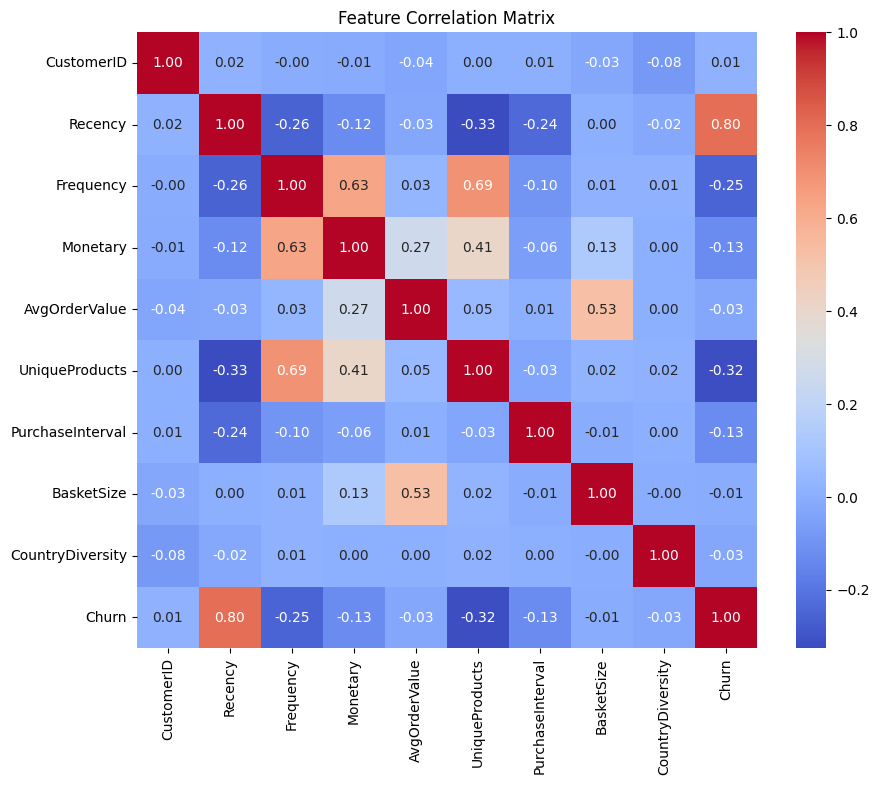

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

plt.title("Feature Correlation Matrix")

plt.show()

In [10]:
features = ['Frequency','Monetary','AvgOrderValue','UniqueProducts','PurchaseInterval','BasketSize','CountryDiversity']

In [11]:
X = df[features]
y = df['Churn']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

In [14]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator= model,
    param_distributions=param_grid,
    n_iter=15,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [15]:
best_model = random_search.best_estimator_

In [16]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [17]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [18]:
confusion_matrix(y_test, y_pred)

array([[378, 200],
       [120, 479]])

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.65      0.70       578
           1       0.71      0.80      0.75       599

    accuracy                           0.73      1177
   macro avg       0.73      0.73      0.73      1177
weighted avg       0.73      0.73      0.73      1177



In [20]:
y_prob = best_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.8033747133342191


In [22]:
import joblib

joblib.dump(best_model, r"D:\Dharmik\Data Scientist(Course)\projects\ML\Retail_brain_ai\models\churn_model.pkl")

['D:\\Dharmik\\Data Scientist(Course)\\projects\\ML\\Retail_brain_ai\\models\\churn_model.pkl']